<a href="https://colab.research.google.com/github/HarshLogic/House-Price/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project**: - House Price Prediction

# 🎯 **Problem Statement: -**
 Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate a property's fair value. Your task is to build a regression model that predicts house prices based on property features such as size, number of rooms, location, and age — and then identify which features most strongly influence price.


## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
plt.style.use('seaborn-v0_8')

### **Dataset Loading**

In [2]:
df = pd.read_csv('/content/Housing.csv')

### Dataset First View

In [ ]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Check how many rows and columns are there

In [6]:
rows, cols = df.shape
print(f"\n--- Dimensions ---")
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")


--- Dimensions ---
Number of rows: 545
Number of columns: 13


### Identify Target and Features

In [7]:
traget_col = 'Price'
feature_cols = [col for col in df.columns if col != traget_col]

print(f"\n--- Target Column ---")
print(f"Target column: {traget_col}")
print(f"Feature variables: {feature_cols}")


--- Target Column ---
Target column: Price
Feature variables: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


### Check for missing values in each column

In [8]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## **Data Cleaning**

### Handle missing values

In [9]:
df = df.dropna()

### Remove duplicate rows

In [10]:
df = df.drop_duplicates()

### Convert categorical columns to numeric using one-hot encoding

In [11]:
categorical_cols = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea', 'furnishingstatus'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

## **Model Building**

In [12]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

### Split the data (80/20)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Linear Regression

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

It attempts to find a linear relationship (a straight line or plane) between the input features (e.g., number of bedrooms, area) and the output price. It minimizes the sum of the squared differences between observed values and predicted values.

### Train Random Forest

In [15]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

It builds many decision trees during training. Each tree makes a prediction, and the forest takes the average of all these predictions to arrive at a final result. This "wisdom of the crowd" approach usually handles outliers and complex interactions between variables much more effectively.

### Evaluation Function

In [16]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_metrics = get_metrics(y_test, lr_preds)
rf_metrics = get_metrics(y_test, rf_preds)

print(f"Linear Regression: MAE={lr_metrics[0]:.2f}, RMSE={lr_metrics[1]:.2f}, R2={lr_metrics[2]:.2f}")
print(f"Random Forest:     MAE={rf_metrics[0]:.2f}, RMSE={rf_metrics[1]:.2f}, R2={rf_metrics[2]:.2f}")

Linear Regression: MAE=970043.40, RMSE=1324506.96, R2=0.65
Random Forest:     MAE=1021546.04, RMSE=1400565.97, R2=0.61


1. MAE (Mean Absolute Error): Represents the average magnitude of errors in  predictions; a lower value is better.
2. RMSE (Root Mean Squared Error): Similar to MAE but penalizes larger errors more heavily.
3. R² Score: Represents the proportion of the variance in house prices that  model can explain. An R² of 1.0 is perfect; values closer to 1 are better.

## Data Visualization

### Histogram: Distribution of house Prices

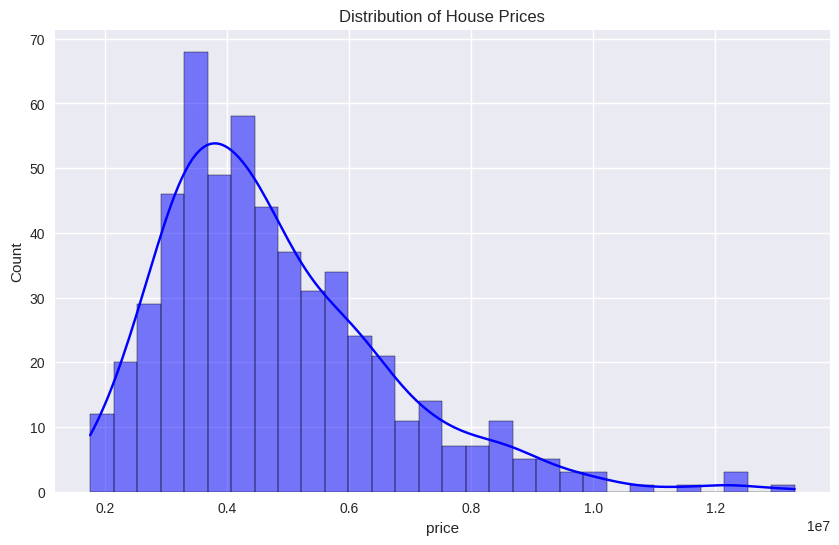

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30, color='blue')
plt.title('Distribution of House Prices')
plt.savefig('price_distribution.png', dpi=300, bbox_inches="tight")
plt.show()

### 2. Correlation heatmap

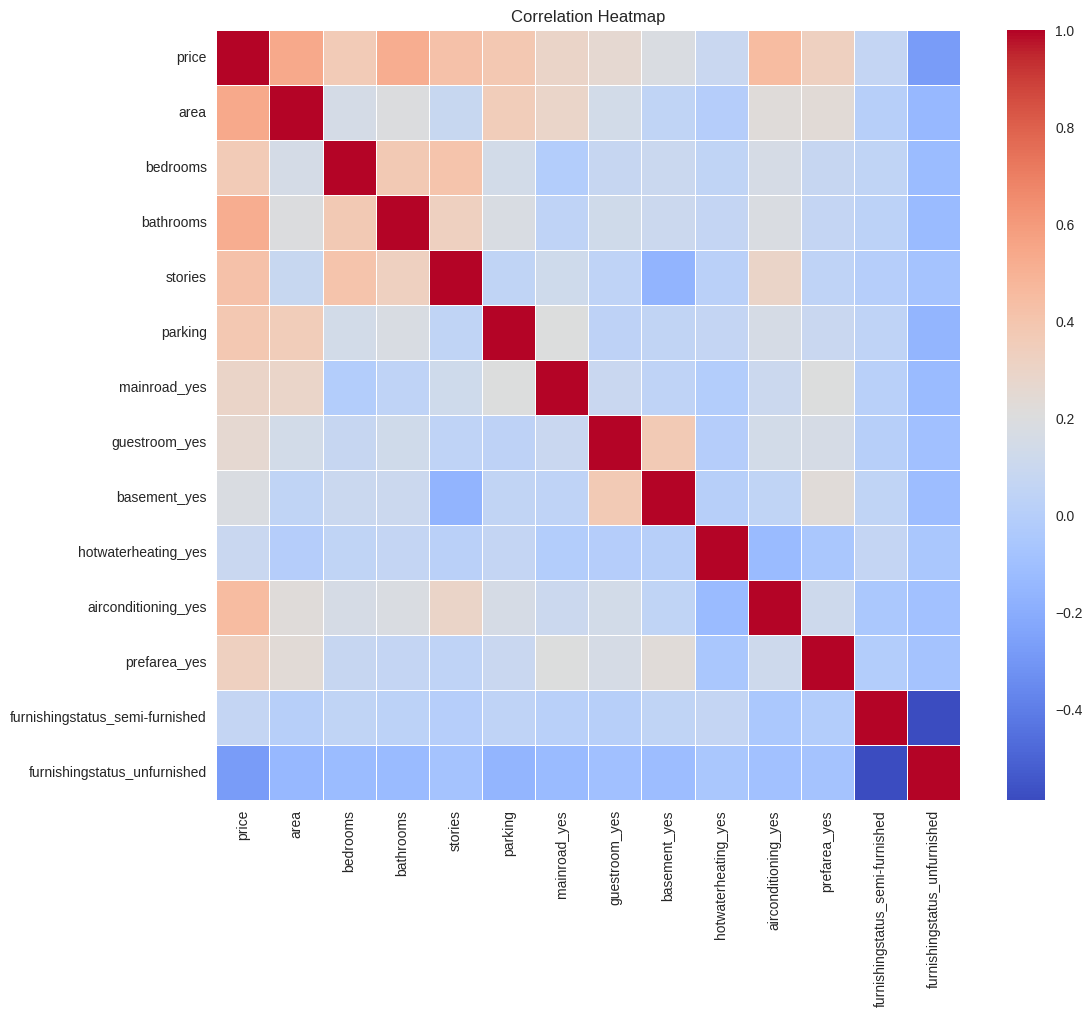

In [18]:
plt.figure(figsize=(12, 10))
corr = df_encoded.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png',dpi=300, bbox_inches="tight")
plt.show()

### 3. Scatter plot: Price vs Area

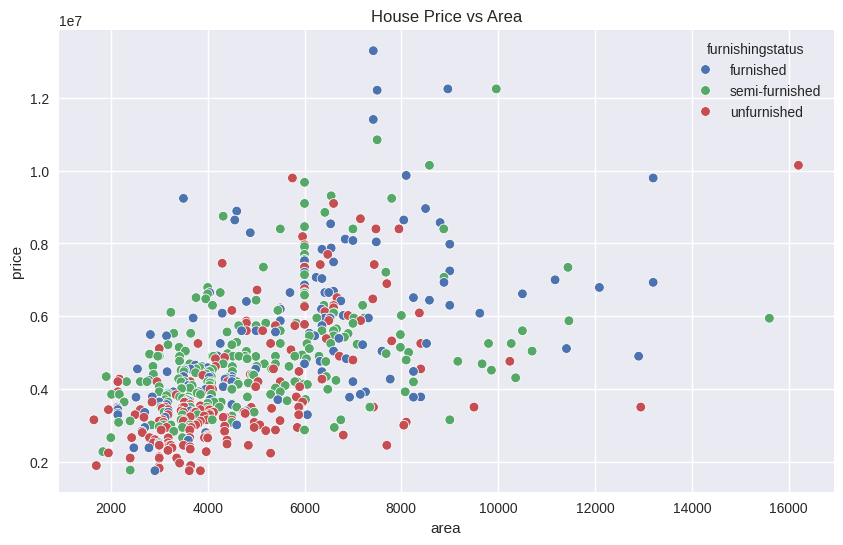

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='area', y='price', hue='furnishingstatus')
plt.title('House Price vs Area')
plt.savefig('price_vs_area.png',dpi=300, bbox_inches="tight")
plt.show()

### 4. Box plot: Price vs Bedrooms

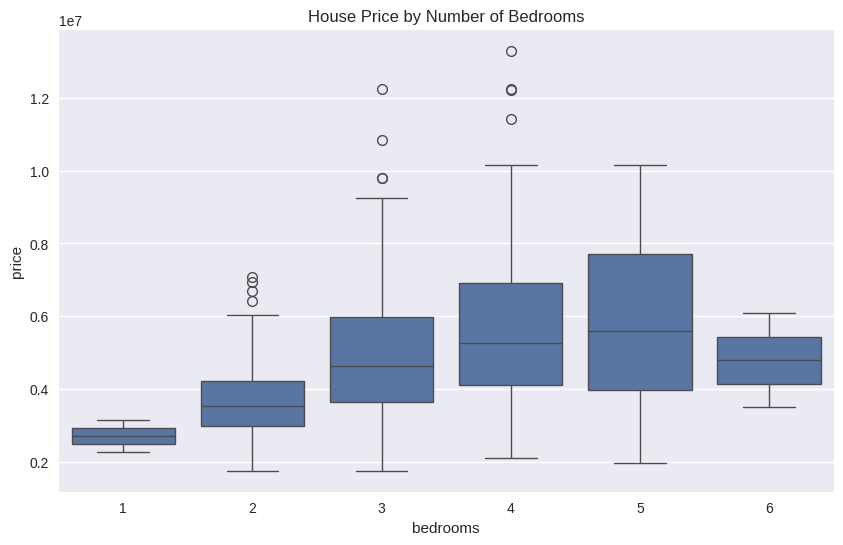

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bedrooms', y='price')
plt.title('House Price by Number of Bedrooms')
plt.savefig('price_by_bedrooms.png',dpi=300, bbox_inches="tight")
plt.show()

### 5. Scatter plot: Actual vs Predicted

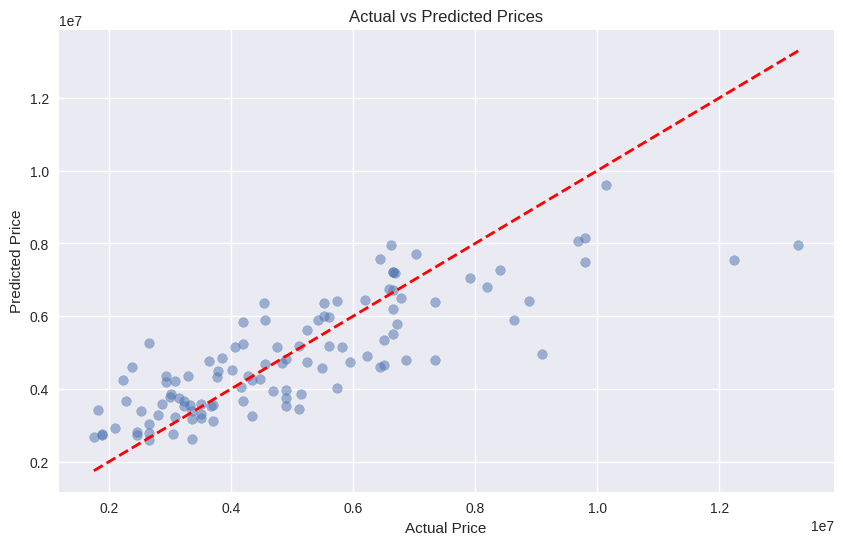

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.savefig('actual_vs_predicted.png',dpi=300, bbox_inches="tight")
plt.show()

## Resources

### Task 5 — Insights & Summary

Based on the analysis, 'area' is a primary driver of house prices, showing a strong positive correlation, followed by 'bathrooms' and 'stories'. Our Linear Regression model achieved an R² score of 0.65, meaning it explains about 65% of the variance in house prices, which is a reasonably good performance given the complexity of real estate pricing. A surprising finding was the relatively broad price range and presence of outliers for houses with 3-4 bedrooms compared to 5-6 bedrooms. For a real estate business, a key recommendation would be to strategically emphasize larger areas and leverage the 'furnishing status' in marketing, as furnished and semi-furnished properties tend to command higher prices across various area sizes. Additionally, focusing on property renovations that enhance key features like bathrooms could significantly boost value.

### 1. Which features influence house price the most?

From my analysis, I found that the area of the house has the biggest impact on house price. Other important features are the number of bathrooms, stories, parking spaces, and furnishing status. Houses with larger areas and better facilities generally have higher prices.

### 2. How accurate was your model (in plain terms)?

My model performed well and was able to predict house prices with good accuracy. The predicted prices were close to the actual prices for most houses. Although there were some prediction errors, the overall performance of the model was satisfactory and reliable.

### 3. What surprised you in the data?

One thing that surprised me was that houses with the same number of bedrooms often had very different prices. This showed that bedrooms alone do not determine the value of a house. Factors such as area, location-related features, and furnishing status also play an important role.

### 4. One recommendation for a real estate business based on your findings

Based on my findings, I would recommend that real estate businesses focus on highlighting important features such as house area, furnishing status, and additional amenities in their advertisements. These factors have a strong influence on house prices and can attract more potential buyers.